In [7]:
import pandas as pd #data handling
import numpy as np #numeric
import matplotlib.pyplot as plt #plots

In [8]:
from google.colab import files
uploaded = files.upload()

Saving 12100168.csv to 12100168.csv


In [9]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,REF_DATE,GEO,DGUID,Trade,Basis,Seasonal adjustment,Index,Weighting,North American Product Classification System (NAPCS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Total of all merchandise,"Index, 2017=100",373,units,0,v1566912759,1.1.1.1.1.1.1,100.6,NaN,NaN,NaN,1
1,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,"Farm, fishing and intermediate food products [...","Index, 2017=100",373,units,0,v1566912760,1.1.1.1.1.1.2,100.3,NaN,NaN,NaN,1
2,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Farm and fishing products [C111],"Index, 2017=100",373,units,0,v1566912761,1.1.1.1.1.1.3,100.1,NaN,NaN,NaN,1
3,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Live animals [111],"Index, 2017=100",373,units,0,v1566912762,1.1.1.1.1.1.4,109.4,NaN,NaN,NaN,1
4,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Wheat [112],"Index, 2017=100",373,units,0,v1566912763,1.1.1.1.1.1.5,94.0,NaN,NaN,NaN,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389052 entries, 0 to 389051
Data columns (total 20 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   REF_DATE                                              389052 non-null  object 
 1   GEO                                                   389052 non-null  object 
 2   DGUID                                                 389052 non-null  object 
 3   Trade                                                 389052 non-null  object 
 4   Basis                                                 389052 non-null  object 
 5   Seasonal adjustment                                   389052 non-null  object 
 6   Index                                                 389052 non-null  object 
 7   Weighting                                             389052 non-null  object 
 8   North American Product Classification System

In [11]:
df.describe()

,UOM_ID,SCALAR_ID,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
count,389052.0,389052.0,389052.000000,0.0,0.0,0.0,389052.0
mean,373.0,0.0,114.179791,NaN,NaN,NaN,1.0
std,0.0,0.0,33.880184,NaN,NaN,NaN,0.0
min,373.0,0.0,0.000000,NaN,NaN,NaN,1.0
25%,373.0,0.0,99.200000,NaN,NaN,NaN,1.0
50%,373.0,0.0,106.600000,NaN,NaN,NaN,1.0
75%,373.0,0.0,124.700000,NaN,NaN,NaN,1.0
max,373.0,0.0,2136.200000,NaN,NaN,NaN,1.0


In [12]:
#Making Sure dates aare in order
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'])
df = df.sort_values('REF_DATE')

In [13]:
df['REF_DATE'].min(), df['REF_DATE'].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2025-11-01 00:00:00'))

In [14]:
df[['REF_DATE']].head()

,REF_DATE
0,2017-01-01
2417,2017-01-01
2418,2017-01-01
2419,2017-01-01
2420,2017-01-01


In [15]:
df[['REF_DATE']].tail()

,REF_DATE
386631,2025-11-01
386632,2025-11-01
386633,2025-11-01
386607,2025-11-01
389051,2025-11-01


In [16]:
df.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Trade', 'Basis', 'Seasonal adjustment',
       'Index', 'Weighting',
       'North American Product Classification System (NAPCS)', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')

In [17]:
df['North American Product Classification System (NAPCS)'].unique()

array(['Total of all merchandise', 'Special transactions trade [988]',
       'Farm, fishing and intermediate food products [C11]',
       'Farm and fishing products [C111]', 'Live animals [111]',
       'Wheat [112]', 'Canola (including rapeseed) [113]',
       'Fresh fruit, nuts and vegetables, and pulse crops [114]',
       'Other crop products [115]', 'Other animal products [116]',
       'Fish, crustaceans, shellfish and other fishery products [121]',
       'Special transactions trade [C231]', 'Animal feed [181]',
       'Intermediate food products [182]', 'Energy products [C12]',
       'Crude oil and crude bitumen [C121]',
       'Crude oil and bitumen [141]',
       'Natural gas, natural gas liquids and related products [C122]',
       'Natural gas [142]',
       'Natural gas liquids (including condensate) and related products [143]',
       'Coal [C123]', 'Coal [144]',
       'Nuclear fuel and other energy products [C124]',
       'Nuclear fuel and other energy products [145]

In [18]:
UniCat = df['North American Product Classification System (NAPCS)'].dropna().sort_values().unique()
UniCat

array(['Agricultural, lawn and garden machinery and equipment [331]',
       'Aircraft [421]',
       'Aircraft and other transportation equipment and parts [C21]',
       'Aircraft engines, aircraft parts and other aerospace equipment [431]',
       'Aircraft, aircraft engines and aircraft parts [C211]',
       'Alcoholic beverages [211]', 'Animal feed [181]',
       'Appliances [382]',
       'Asphalt (except natural) and asphalt products [262]',
       'Basic and industrial chemical, plastic and rubber products [C15]',
       'Basic and semi-finished iron or steel products [312]',
       'Basic and semi-finished products of aluminum and aluminum alloys [327]',
       'Basic and semi-finished products of non-ferrous metals and non-ferrous metal alloys (except aluminum) [326]',
       'Basic chemicals [271]',
       'Basic chemicals and industrial chemical products [C151]',
       'Boats and other transportation equipment [442]',
       'Building and packaging materials [C163]',
     

In [19]:
df['North American Product Classification System (NAPCS)'].value_counts()

,count
North American Product Classification System (NAPCS),
Total of all merchandise,2568
Special transactions trade [988],2568
"Farm, fishing and intermediate food products [C11]",2568
Farm and fishing products [C111],2568
Live animals [111],2568
...,...
"Agricultural, lawn and garden machinery and equipment [331]",2568
"Logging, construction, mining, and oil and gas field machinery and equipment [332]",2568
Other balance of payments adjustments [C24],1284


In [20]:
catCol = 'North American Product Classification System (NAPCS)'

catTable = pd.DataFrame(
    df[catCol].dropna().unique(),
    columns=['Category']
)

catTable

,Category
0,Total of all merchandise
1,Special transactions trade [988]
2,"Farm, fishing and intermediate food products [..."
3,Farm and fishing products [C111]
4,Live animals [111]
...,...
148,"Agricultural, lawn and garden machinery and eq..."
149,"Logging, construction, mining, and oil and gas..."
150,Other balance of payments adjustments [C24]
151,Other balance of payments adjustments [C241]


In [21]:
selectedGroups = [
    "Furniture and fixtures [C225]","Furniture and fixtures [391]",
    "Clothing, footwear and textile products [C222]", "Clothing, footwear and accessories [231]",
    "Canola (including rapeseed) [113]",
    "Fresh fruit, nuts and vegetables, and pulse crops [114]"
]

dfFiltered = df[df['North American Product Classification System (NAPCS)'].isin(selectedGroups)]

dfFiltered

,REF_DATE,GEO,DGUID,Trade,Basis,Seasonal adjustment,Index,Weighting,North American Product Classification System (NAPCS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
2423,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Laspeyres fixed weighted,Canola (including rapeseed) [113],"Index, 2017=100",373,units,0,v1566915182,1.2.1.2.1.2.6,98.4,NaN,NaN,NaN,1
2424,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Laspeyres fixed weighted,"Fresh fruit, nuts and vegetables, and pulse cr...","Index, 2017=100",373,units,0,v1566915183,1.2.1.2.1.2.7,100.7,NaN,NaN,NaN,1
2399,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Paasche current weighted,"Clothing, footwear and textile products [C222]","Index, 2017=100",373,units,0,v1566915158,1.2.1.2.1.1.132,100.2,NaN,NaN,NaN,1
2409,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Paasche current weighted,Furniture and fixtures [C225],"Index, 2017=100",373,units,0,v1566915168,1.2.1.2.1.1.142,99.8,NaN,NaN,NaN,1
2410,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Paasche current weighted,Furniture and fixtures [391],"Index, 2017=100",373,units,0,v1566915169,1.2.1.2.1.1.143,99.8,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386602,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Price index,Laspeyres fixed weighted,"Clothing, footwear and accessories [231]","Index, 2017=100",373,units,0,v1566913945,1.1.2.1.1.2.134,101.7,NaN,NaN,NaN,1
386610,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Price index,Laspeyres fixed weighted,Furniture and fixtures [C225],"Index, 2017=100",373,units,0,v1566913953,1.1.2.1.1.2.142,132.7,NaN,NaN,NaN,1
386611,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Price index,Laspeyres fixed weighted,Furniture and fixtures [391],"Index, 2017=100",373,units,0,v1566913954,1.1.2.1.1.2.143,132.7,NaN,NaN,NaN,1
386627,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Volume index,Laspeyres fixed weighted,Canola (including rapeseed) [113],"Index, 2017=100",373,units,0,v1566913970,1.1.2.1.2.2.6,166.9,NaN,NaN,NaN,1


In [22]:
dfSelected = df[df[catCol].isin(selectedGroups)].copy()

dfSelected[catCol].value_counts()

,count
North American Product Classification System (NAPCS),
Canola (including rapeseed) [113],2568
"Fresh fruit, nuts and vegetables, and pulse crops [114]",2568
"Clothing, footwear and textile products [C222]",2568
Furniture and fixtures [C225],2568
Furniture and fixtures [391],2568
"Clothing, footwear and accessories [231]",2568


In [23]:
trade = 'Trade'
index = 'Index'
seasonal = 'Seasonal adjustment'
weight = 'Weighting'
basis = 'Basis'

In [24]:
dfModelBase = dfSelected[
    (dfSelected[trade] == 'Import') &   # Imports only for import demand
    (dfSelected[index] == 'Volume index') & # volume index means quantity(or demand)
    (dfSelected[seasonal] == 'Seasonally adjusted') & #keeping only seasonally adjusted data for now, will revisit this later
    (dfSelected[basis] == 'Customs') #measuring only on basis of customs    #used & to make sure all conditions are true.
].copy()

print("Rows after Import+Volume+SA+Customs:", len(dfModelBase))

Rows after Import+Volume+SA+Customs: 642


In [25]:
dfEda = dfSelected[
    (dfSelected['Trade'] == 'Import') &
    (dfSelected['Index'] == 'Volume index')
].copy()

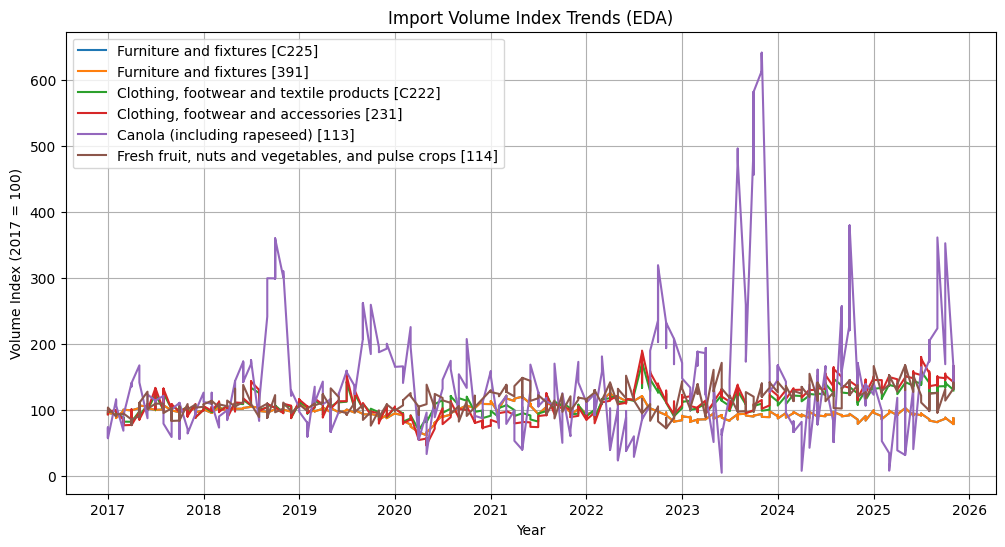

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for group in selectedGroups:
    subsetDf = dfEda[dfEda[catCol] == group].sort_values('REF_DATE')
    plt.plot(subsetDf['REF_DATE'], subsetDf['VALUE'], label=group)

plt.title("Import Volume Index Trends (EDA)")
plt.xlabel("Year")
plt.ylabel("Volume Index (2017 = 100)")
plt.legend()
plt.grid(True)
plt.show()

In [27]:

def group_category(category):
    if category in ["Furniture and fixtures [C225]", "Furniture and fixtures [391]"]:
        return "Furniture and Fixtures"
    elif category in ["Clothing, footwear and textile products [C222]", "Clothing, footwear and accessories [231]"]:
        return "Clothing and Footwear"
    elif category in ["Canola (including rapeseed) [113]", "Fresh fruit, nuts and vegetables, and pulse crops [114]"]:
        return "Agricultural Products"
    return category

dfEda['Grouped Category'] = dfEda[catCol].apply(group_category)
dfEda['Grouped Category'].value_counts()

,count
Grouped Category,
Clothing and Footwear,856
Furniture and Fixtures,856
Agricultural Products,856


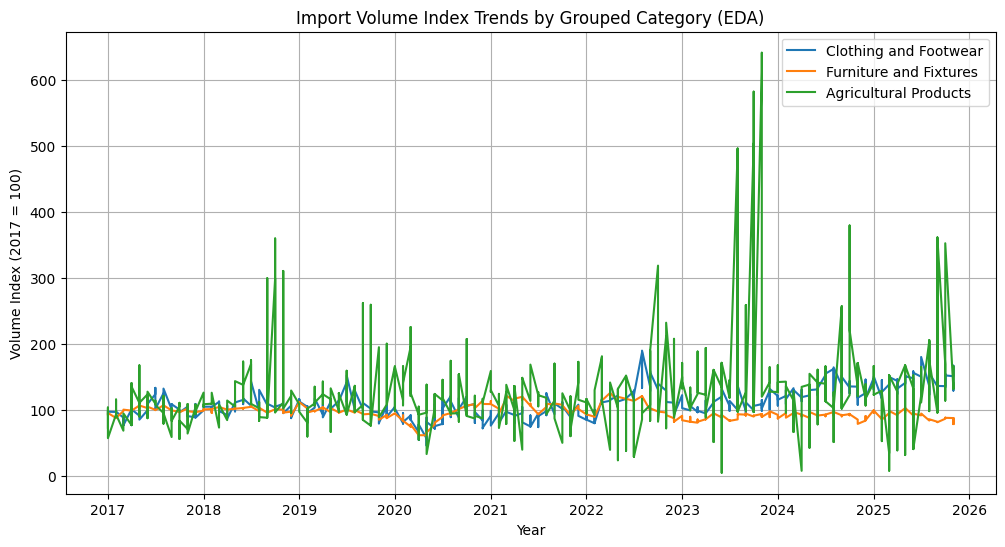

In [28]:
plt.figure(figsize=(12, 6))

for group in dfEda['Grouped Category'].unique():
    subsetDf = dfEda[dfEda['Grouped Category'] == group].sort_values('REF_DATE')
    plt.plot(subsetDf['REF_DATE'], subsetDf['VALUE'], label=group)

plt.title("Import Volume Index Trends by Grouped Category (EDA)")
plt.xlabel("Year")
plt.ylabel("Volume Index (2017 = 100)")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelDf = dfModelBase.copy()

modelDf["groupedCategory"] = modelDf["North American Product Classification System (NAPCS)"].apply(group_category) #grouping categories

#Group data by month and grouped categgory
modelDf = (
    modelDf.groupby(["REF_DATE", "groupedCategory"], as_index=False)["VALUE"]
    .mean()
    .sort_values(["groupedCategory", "REF_DATE"])
)


modelDf.head()

,REF_DATE,groupedCategory,VALUE
0,2017-01-01,Agricultural Products,85.60
3,2017-02-01,Agricultural Products,103.20
6,2017-03-01,Agricultural Products,81.85
9,2017-04-01,Agricultural Products,106.90
12,2017-05-01,Agricultural Products,129.60


In [30]:
modelDf = modelDf.rename(columns={"VALUE": "volumeIndex"})
modelDf.head()

,REF_DATE,groupedCategory,volumeIndex
0,2017-01-01,Agricultural Products,85.60
3,2017-02-01,Agricultural Products,103.20
6,2017-03-01,Agricultural Products,81.85
9,2017-04-01,Agricultural Products,106.90
12,2017-05-01,Agricultural Products,129.60


In [31]:
modelDf = modelDf.sort_values(["groupedCategory", "REF_DATE"])

for lag in [1, 3, 6, 12]:
    modelDf[f"lag_{lag}"] = modelDf.groupby("groupedCategory")["volumeIndex"].shift(lag)

modelDf.head(15)

,REF_DATE,groupedCategory,volumeIndex,lag_1,lag_3,lag_6,lag_12
0,2017-01-01,Agricultural Products,85.60,NaN,NaN,NaN,NaN
3,2017-02-01,Agricultural Products,103.20,85.60,NaN,NaN,NaN
6,2017-03-01,Agricultural Products,81.85,103.20,NaN,NaN,NaN
9,2017-04-01,Agricultural Products,106.90,81.85,85.60,NaN,NaN
12,2017-05-01,Agricultural Products,129.60,106.90,103.20,NaN,NaN
15,2017-06-01,Agricultural Products,113.25,129.60,81.85,NaN,NaN
18,2017-07-01,Agricultural Products,108.70,113.25,106.90,85.60,NaN
21,2017-08-01,Agricultural Products,116.10,108.70,129.60,103.20,NaN
24,2017-09-01,Agricultural Products,81.40,116.10,113.25,81.85,NaN
27,2017-10-01,Agricultural Products,81.15,81.40,108.70,106.90,NaN


In [32]:
modelDf["rollingMean_3"] = (
    modelDf.groupby("groupedCategory")["volumeIndex"]
    .transform(lambda s: s.shift(1).rolling(3).mean())
)

modelDf["rollingMean_6"] = (
    modelDf.groupby("groupedCategory")["volumeIndex"]
    .transform(lambda s: s.shift(1).rolling(6).mean())
)

modelDf.head(15)

,REF_DATE,groupedCategory,volumeIndex,lag_1,lag_3,lag_6,lag_12,rollingMean_3,rollingMean_6
0,2017-01-01,Agricultural Products,85.60,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-02-01,Agricultural Products,103.20,85.60,NaN,NaN,NaN,NaN,NaN
6,2017-03-01,Agricultural Products,81.85,103.20,NaN,NaN,NaN,NaN,NaN
9,2017-04-01,Agricultural Products,106.90,81.85,85.60,NaN,NaN,90.216667,NaN
12,2017-05-01,Agricultural Products,129.60,106.90,103.20,NaN,NaN,97.316667,NaN
15,2017-06-01,Agricultural Products,113.25,129.60,81.85,NaN,NaN,106.116667,NaN
18,2017-07-01,Agricultural Products,108.70,113.25,106.90,85.60,NaN,116.583333,103.400000
21,2017-08-01,Agricultural Products,116.10,108.70,129.60,103.20,NaN,117.183333,107.250000
24,2017-09-01,Agricultural Products,81.40,116.10,113.25,81.85,NaN,112.683333,109.400000
27,2017-10-01,Agricultural Products,81.15,81.40,108.70,106.90,NaN,102.066667,109.325000


In [33]:
import numpy as np

modelDf["covidDummy"] = np.where(
    (modelDf["REF_DATE"] >= "2020-01-01") & (modelDf["REF_DATE"] <= "2021-12-31"),
    1,
    0
)

modelDf.head()

,REF_DATE,groupedCategory,volumeIndex,lag_1,lag_3,lag_6,lag_12,rollingMean_3,rollingMean_6,covidDummy
0,2017-01-01,Agricultural Products,85.60,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2017-02-01,Agricultural Products,103.20,85.60,NaN,NaN,NaN,NaN,NaN,0
6,2017-03-01,Agricultural Products,81.85,103.20,NaN,NaN,NaN,NaN,NaN,0
9,2017-04-01,Agricultural Products,106.90,81.85,85.6,NaN,NaN,90.216667,NaN,0
12,2017-05-01,Agricultural Products,129.60,106.90,103.2,NaN,NaN,97.316667,NaN,0


In [34]:
modelDfClean = modelDf.dropna().copy()
modelDfClean.shape

(285, 10)

In [35]:
trainDf = modelDfClean[modelDfClean["REF_DATE"] < "2024-01-01"].copy()
testDf = modelDfClean[modelDfClean["REF_DATE"] >= "2024-01-01"].copy()

print(trainDf["REF_DATE"].min(), trainDf["REF_DATE"].max())
print(testDf["REF_DATE"].min(), testDf["REF_DATE"].max())

2018-01-01 00:00:00 2023-12-01 00:00:00
2024-01-01 00:00:00 2025-11-01 00:00:00


In [36]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error

naiveResults = []

for group in testDf["groupedCategory"].unique():
    testGroup = testDf[testDf["groupedCategory"] == group].copy()

    yTrue = testGroup["volumeIndex"]
    yPred = testGroup["lag_1"]

    rmse = math.sqrt(mean_squared_error(yTrue, yPred))
    mae = mean_absolute_error(yTrue, yPred)

    naiveResults.append({
        "groupedCategory": group,
        "model": "Naive",
        "RMSE": rmse,
        "MAE": mae
    })

naiveResultsDf = pd.DataFrame(naiveResults)
naiveResultsDf

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Naive,24.414979,19.693478
1,Clothing and Footwear,Naive,6.857200,5.450000
2,Furniture and Fixtures,Naive,4.789708,3.900000


In [37]:
seasonalNaiveResults = []

for group in testDf["groupedCategory"].unique():
    testGroup = testDf[testDf["groupedCategory"] == group].copy()

    yTrue = testGroup["volumeIndex"]
    yPred = testGroup["lag_12"]

    rmse = math.sqrt(mean_squared_error(yTrue, yPred))
    mae = mean_absolute_error(yTrue, yPred)

    seasonalNaiveResults.append({
        "groupedCategory": group,
        "model": "Seasonal Naive",
        "RMSE": rmse,
        "MAE": mae
    })

seasonalNaiveResultsDf = pd.DataFrame(seasonalNaiveResults)
seasonalNaiveResultsDf

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Seasonal Naive,75.157534,42.315217
1,Clothing and Footwear,Seasonal Naive,20.122219,17.278261
2,Furniture and Fixtures,Seasonal Naive,6.224286,5.086957


In [38]:
baselineResultsDf = pd.concat([naiveResultsDf, seasonalNaiveResultsDf], ignore_index=True)
baselineResultsDf.sort_values(["groupedCategory", "RMSE"])

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Naive,24.414979,19.693478
3,Agricultural Products,Seasonal Naive,75.157534,42.315217
1,Clothing and Footwear,Naive,6.857200,5.450000
4,Clothing and Footwear,Seasonal Naive,20.122219,17.278261
2,Furniture and Fixtures,Naive,4.789708,3.900000
5,Furniture and Fixtures,Seasonal Naive,6.224286,5.086957


In [39]:
from sklearn.linear_model import LinearRegression

lrResults = []
# Create lag features for time-series modeling
features = ["lag_1", "lag_3", "lag_6", "lag_12", "rollingMean_3", "rollingMean_6", "covidDummy"]

for group in testDf["groupedCategory"].unique():
    trainGroup = trainDf[trainDf["groupedCategory"] == group]
    testGroup = testDf[testDf["groupedCategory"] == group]

    X_train = trainGroup[features]
    y_train = trainGroup["volumeIndex"]

    X_test = testGroup[features]
    y_test = testGroup["volumeIndex"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    lrResults.append({
        "groupedCategory": group,
        "model": "Linear Regression",
        "RMSE": rmse,
        "MAE": mae
    })

lrResultsDf = pd.DataFrame(lrResults)
lrResultsDf

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Linear Regression,34.528317,25.799596
1,Clothing and Footwear,Linear Regression,15.322257,13.732649
2,Furniture and Fixtures,Linear Regression,5.360131,4.455533


In [40]:
allResultsDf = pd.concat([baselineResultsDf, lrResultsDf], ignore_index=True)
allResultsDf.sort_values(["groupedCategory", "RMSE"])

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Naive,24.414979,19.693478
6,Agricultural Products,Linear Regression,34.528317,25.799596
3,Agricultural Products,Seasonal Naive,75.157534,42.315217
1,Clothing and Footwear,Naive,6.857200,5.450000
7,Clothing and Footwear,Linear Regression,15.322257,13.732649
4,Clothing and Footwear,Seasonal Naive,20.122219,17.278261
2,Furniture and Fixtures,Naive,4.789708,3.900000
8,Furniture and Fixtures,Linear Regression,5.360131,4.455533
5,Furniture and Fixtures,Seasonal Naive,6.224286,5.086957


In [41]:
from sklearn.ensemble import RandomForestRegressor

rfResults = []

features = ["lag_1", "lag_3", "lag_6", "lag_12", "rollingMean_3", "rollingMean_6", "covidDummy"]

for group in testDf["groupedCategory"].unique():
    trainGroup = trainDf[trainDf["groupedCategory"] == group]
    testGroup = testDf[testDf["groupedCategory"] == group]

    X_train = trainGroup[features]
    y_train = trainGroup["volumeIndex"]

    X_test = testGroup[features]
    y_test = testGroup["volumeIndex"]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    rfResults.append({
        "groupedCategory": group,
        "model": "Random Forest",
        "RMSE": rmse,
        "MAE": mae
    })

rfResultsDf = pd.DataFrame(rfResults)
rfResultsDf

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Random Forest,47.235104,33.764152
1,Clothing and Footwear,Random Forest,19.464440,17.556848
2,Furniture and Fixtures,Random Forest,5.279672,4.674870


In [42]:
allResultsDf = pd.concat([baselineResultsDf, lrResultsDf, rfResultsDf], ignore_index=True)
allResultsDf.sort_values(["groupedCategory", "RMSE"])

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Naive,24.414979,19.693478
6,Agricultural Products,Linear Regression,34.528317,25.799596
9,Agricultural Products,Random Forest,47.235104,33.764152
3,Agricultural Products,Seasonal Naive,75.157534,42.315217
1,Clothing and Footwear,Naive,6.857200,5.450000
7,Clothing and Footwear,Linear Regression,15.322257,13.732649
10,Clothing and Footwear,Random Forest,19.464440,17.556848
4,Clothing and Footwear,Seasonal Naive,20.122219,17.278261
2,Furniture and Fixtures,Naive,4.789708,3.900000
11,Furniture and Fixtures,Random Forest,5.279672,4.674870


In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimaResults = []

for group in testDf["groupedCategory"].unique():
    trainGroup = trainDf[trainDf["groupedCategory"] == group]
    testGroup = testDf[testDf["groupedCategory"] == group]

    y_train = trainGroup["volumeIndex"]
    y_test = testGroup["volumeIndex"]

    # Simple SARIMA model (can tune later)
    model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12))
    model_fit = model.fit(disp=False)

    forecast = model_fit.forecast(steps=len(y_test))

    rmse = math.sqrt(mean_squared_error(y_test, forecast))
    mae = mean_absolute_error(y_test, forecast)

    sarimaResults.append({
        "groupedCategory": group,
        "model": "SARIMA",
        "RMSE": rmse,
        "MAE": mae
    })

sarimaResultsDf = pd.DataFrame(sarimaResults)
sarimaResultsDf

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,SARIMA,198.299281,172.750349
1,Clothing and Footwear,SARIMA,19.570867,17.626858
2,Furniture and Fixtures,SARIMA,6.823181,5.651476


In [44]:
finalResultsDf = pd.concat(
    [baselineResultsDf, lrResultsDf, rfResultsDf, sarimaResultsDf],
    ignore_index=True
)

finalResultsDf.sort_values(["groupedCategory", "RMSE"])

,groupedCategory,model,RMSE,MAE
0,Agricultural Products,Naive,24.414979,19.693478
6,Agricultural Products,Linear Regression,34.528317,25.799596
9,Agricultural Products,Random Forest,47.235104,33.764152
3,Agricultural Products,Seasonal Naive,75.157534,42.315217
12,Agricultural Products,SARIMA,198.299281,172.750349
1,Clothing and Footwear,Naive,6.857200,5.450000
7,Clothing and Footwear,Linear Regression,15.322257,13.732649
10,Clothing and Footwear,Random Forest,19.464440,17.556848
13,Clothing and Footwear,SARIMA,19.570867,17.626858
4,Clothing and Footwear,Seasonal Naive,20.122219,17.278261


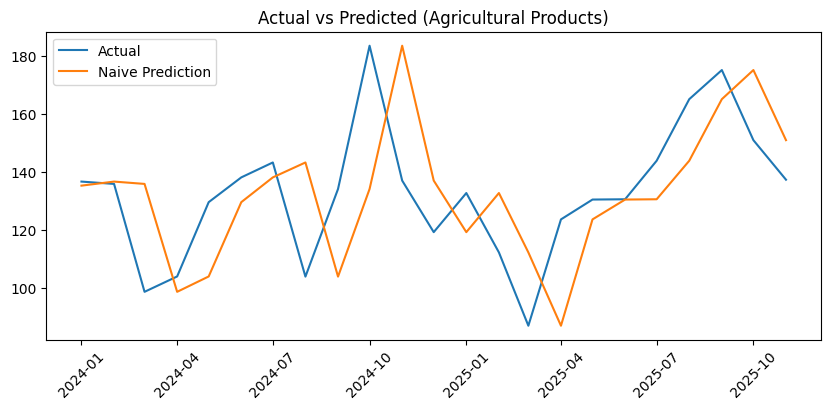

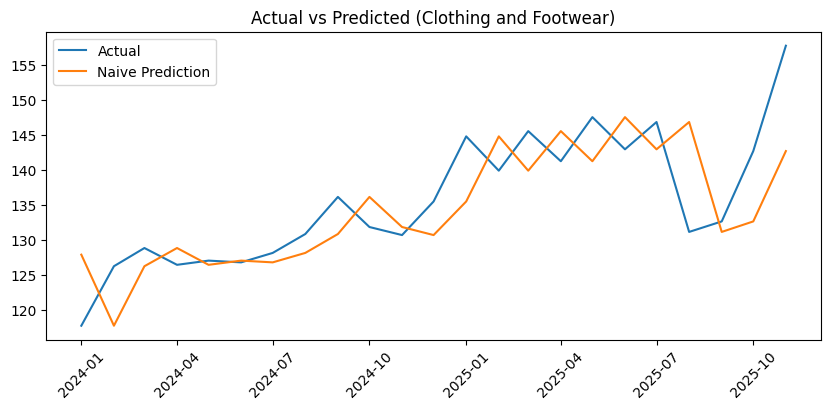

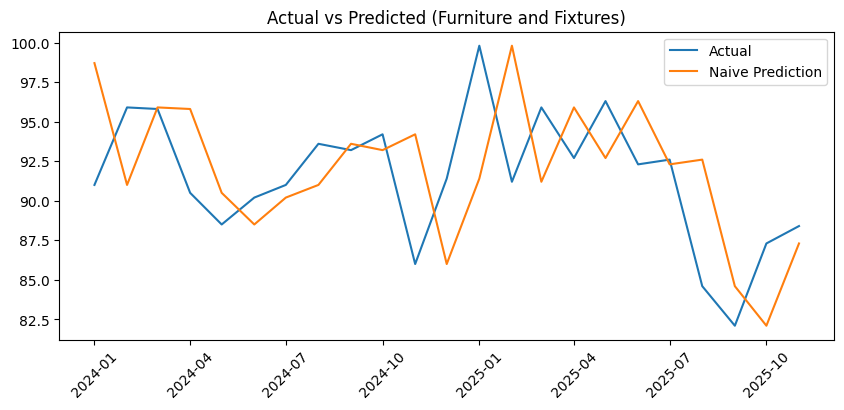

In [45]:
for group in testDf["groupedCategory"].unique():
    testGroup = testDf[testDf["groupedCategory"] == group]

    plt.figure(figsize=(10,4))
    plt.plot(testGroup["REF_DATE"], testGroup["volumeIndex"], label="Actual")
    plt.plot(testGroup["REF_DATE"], testGroup["lag_1"], label="Naive Prediction")

    plt.title(f"Actual vs Predicted ({group})")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

The plots show that the naïve model closely follows actual values, particularly in stable categories such as Furniture and Fixtures. However, deviations are observed in more volatile categories like Agricultural Products, confirming the higher error values observed in the evaluation metrics.